# FIGS — Case Analysis & Display

Run (or load) a forecast for a HRRR cycle, render SPC-style probability /
categorical / median-intensity maps, and overlay the observed storm reports.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs` works from notebooks/
from figs import config as C

In [2]:
from datetime import datetime, timezone, timedelta
from figs.model.predict import predict_forecast
from figs.products import plots, summary, cig, netcdf
from figs.data import reports, grid

# RUN   = datetime(2021, 3, 25, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2023, 4, 19, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 5, 6, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 5, 23, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2021, 12, 10, 21, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2022, 11, 29, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2026, 6, 18, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 10, 9, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 7, 8, 15, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 4, 2, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2025, 6, 20, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2025, 6, 16, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2023, 6, 21, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2023, 6, 23, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2022, 5, 23, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 4, 26, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2025, 3, 14, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2026, 6, 20, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
RUN   = datetime(2026, 6, 21, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# FXX   = list(range(1, 13))                              # forecast hours
FXX   = list(range(1, 19))                              # forecast hours
# FXX   = list(range(1, 10))                              # forecast hours
MODELS = None                                           # None -> Data/models
DL_WORKERS = 8                                          # forecast hours downloaded concurrently
# DL_WORKERS = 4                                          # forecast hours downloaded concurrently

## Predict (or load a prepared netCDF)

In [3]:
from figs.model.predict import predict_or_load
try:
    # loads the run's netCDF if it exists (no re-download), else forecasts + writes it;
    # transient HRRR S3 errors (e.g. 503) are retried. Pass cache=False to force recompute.
    preds = predict_or_load(RUN, FXX, models_dir=MODELS, max_members=6, workers=DL_WORKERS)
    print(f'{len(preds)} forecast hours | netCDF: {netcdf.predictions_path(RUN, fxx=FXX)}')
except Exception as e:
    print('predict failed (need trained models?):', e)
    preds = None

[predict] f01: downloading + preprocessing…
[predict] f02: downloading + preprocessing…
[predict] f03: downloading + preprocessing…
[predict] f04: downloading + preprocessing…
[predict] f05: downloading + preprocessing…
[predict] f06: downloading + preprocessing…
[predict] f07: downloading + preprocessing…
[predict] f08: downloading + preprocessing…
[predict] f01: preprocessed ✓ — predicting
[predict] f02: preprocessed ✓ — predicting
[predict] f03: preprocessed ✓ — predicting
[predict] f04: preprocessed ✓ — predicting
[predict] f07: preprocessed ✓ — predicting
[predict] f05: preprocessed ✓ — predicting
[predict] f06: preprocessed ✓ — predicting
[predict] f08: preprocessed ✓ — predicting
[predict] f09: downloading + preprocessing…
[predict] 1/18 (5%) complete — f01 done
[predict] f10: downloading + preprocessing…
[predict] 2/18 (11%) complete — f02 done
[predict] f11: downloading + preprocessing…
[predict] 3/18 (16%) complete — f03 done
[predict] f12: downloading + preprocessing…
[predi

## Map extent

Plan-view extent `[lon_min, lon_max, lat_min, lat_max]` for ALL plots below — kept
in its own cell AFTER predict so you can re-tune the zoom and re-run just the plots
without re-forecasting. `None` lets cartopy auto-fit the FIGS grid.

In [4]:
# MAP_EXTENT = [-110, -80, 25, 55]
# MAP_EXTENT = [-95, -80, 30, 45] # Ohio river valley
MAP_EXTENT = [-105, -85, 25, 45] # Midwest
# MAP_EXTENT = [-95, -80, 25, 40] # Dixie
# MAP_EXTENT = [-100, -80, 20, 40] # Dixie
# MAP_EXTENT = [-105, -90, 30, 45] # Plains
# MAP_EXTENT = [-105, -90, 35, 50] # Plains
# MAP_EXTENT = [-110, -95, 35, 50] # High Plains
# MAP_EXTENT = [-85, -78, 23, 30] # Milton
plots.set_extent(MAP_EXTENT)
HAZARD = 'tor'                                          # 'tor' | 'wind' | 'hail'
# HAZARD = 'wind'                                          # 'tor' | 'wind' | 'hail'
# HAZARD = 'hail'                                          # 'tor' | 'wind' | 'hail'

## Per-forecast-hour SPC-style maps — animated over the whole period

Two looping GIFs over **every** forecast hour in `FXX` (no single-hour selector — the animation spans the entire inference period): the `HAZARD` probability+CIG map, and the categorical map which is ALWAYS across all 3 hazards (SPC-style max category over tor/wind/hail).

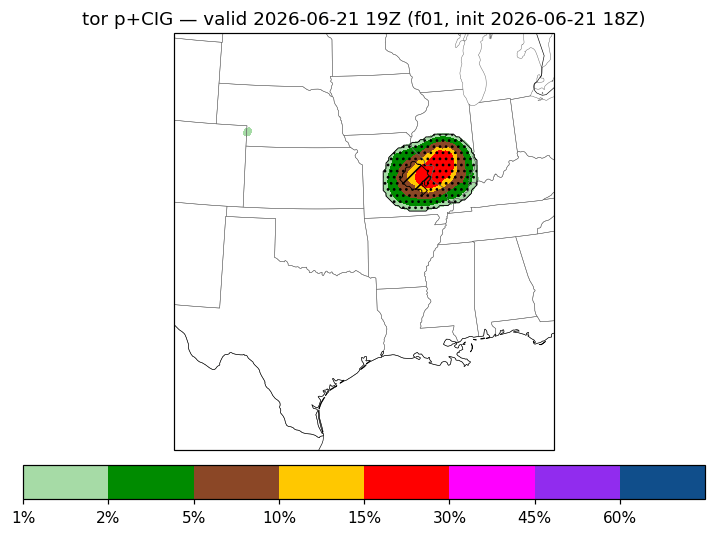

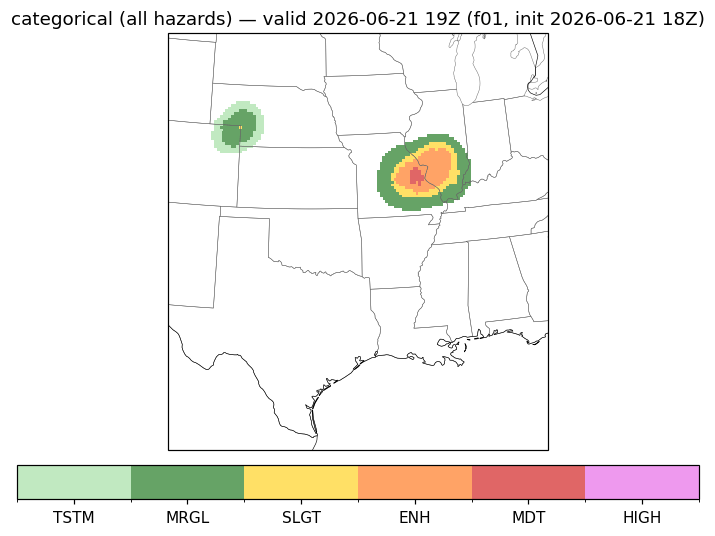

In [5]:
if preds:
    from IPython.display import Image, display
    from figs.products import animate
    prob_frames, cat_frames = [], []
    for f in sorted(FXX):
        p = preds[f][f'p_{HAZARD}']
        dist = np.nan_to_num(preds[f][f'dist_{HAZARD}'])
        cig_idx = cig.derive_cig_category(HAZARD, dist)
        vt = RUN + timedelta(hours=f)
        ttl = f'valid {vt:%Y-%m-%d %HZ} (f{f:02d}, init {RUN:%Y-%m-%d %HZ})'
        prob_frames.append(plots.plot_probability(p, HAZARD, f'{HAZARD} p+CIG — {ttl}', f'/tmp/_p_{f:02d}.png', cig=cig_idx))
        # categorical is ALWAYS across all 3 hazards (max category over tor/wind/hail)
        cat = np.maximum.reduce([cig.categorical_risk(h, preds[f][f'p_{h}']*100, np.nan_to_num(preds[f][f'dist_{h}']))['category'] for h in C.HAZARDS])
        cat_frames.append(plots.plot_categorical(cat, 'all', f'categorical (all hazards) — {ttl}', f'/tmp/_c_{f:02d}.png'))
    pgif = animate.make_gif(prob_frames, '/tmp/_p.gif', duration_ms=600)
    cgif = animate.make_gif(cat_frames, '/tmp/_c.gif', duration_ms=600)
    display(Image(pgif)); display(Image(cgif))

### Hour-by-hour probability validation (selected `HAZARD`)

Looping GIF over every forecast hour: the `HAZARD` probability field with the **observed reports within ±30 min of each valid hour** overlaid (`×`), so you can watch the forecast probability track the reports through the period.

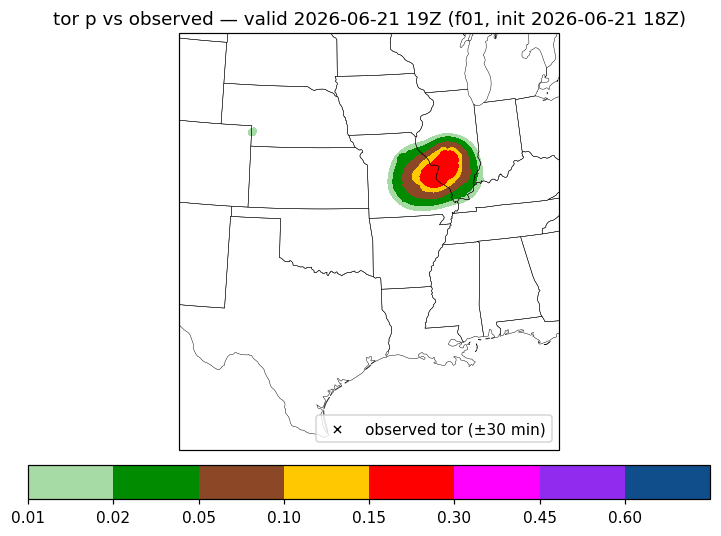

In [6]:
if preds:
    from IPython.display import Image, display
    from figs.products import animate
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    from figs.data.grid import figs_latlon
    lat, lon = figs_latlon()
    proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
    levels = list(C.SPC_PROB_LEVELS[HAZARD]) + [1.0]
    # observed HAZARD reports across the whole forecast valid window (fetched once);
    # each frame overlays the ones within ±30 min of that hour (the labeling window).
    _v0 = RUN + timedelta(hours=min(FXX)); _v1 = RUN + timedelta(hours=max(FXX))
    _udays = sorted({_v0.replace(hour=0,minute=0,second=0,microsecond=0),
                     _v1.replace(hour=0,minute=0,second=0,microsecond=0)})
    rep_win = pd.concat([reports.reports_for_day(d) for d in _udays], ignore_index=True)
    rep_win = rep_win[rep_win.hazard == HAZARD]
    val_frames = []
    for f in sorted(FXX):
        vt = RUN + timedelta(hours=f)
        r = rep_win[(rep_win.time >= vt - timedelta(minutes=30)) & (rep_win.time <= vt + timedelta(minutes=30))]
        fig = plt.figure(figsize=(10,6)); ax = plt.axes(projection=proj)
        ax.add_feature(cfeature.STATES, lw=0.3)
        if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
        cf = ax.contourf(lon, lat, preds[f][f'p_{HAZARD}'], levels=levels, colors=plots.PROB_COLORS[HAZARD],
                         transform=ccrs.PlateCarree(), extend='neither')
        ax.scatter(r.lon, r.lat, s=22, c='black', marker='x', lw=0.9, transform=ccrs.PlateCarree(),
                   label=f'observed {HAZARD} (±30 min)')
        plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, ticks=C.SPC_PROB_LEVELS[HAZARD])
        ax.legend(loc='lower right')
        ax.set_title(f'{HAZARD} p vs observed — valid {vt:%Y-%m-%d %HZ} (f{f:02d}, init {RUN:%Y-%m-%d %HZ})')
        path = f'/tmp/_val_{f:02d}.png'; fig.savefig(path, dpi=110, bbox_inches='tight'); plt.close(fig)
        val_frames.append(path)
    vgif = animate.make_gif(val_frames, '/tmp/_val.gif', duration_ms=600)
    display(Image(vgif))

## Day-total (cumulative) risk + median / 75th / 90th / 99th-pct intensity

The cumulative daily **categorical** outlook is ALWAYS across all 3 hazards (the SPC Day-1 categorical = max category over tor/wind/hail). **Day-max** conditional-intensity is shown for the **selected `HAZARD`** at the **median**, **75th**, **90th** and **99th percentile** (per-hour percentile bin, maxed over hours), masked to that hazard's threat area (day-max prob ≥ its lowest SPC level).

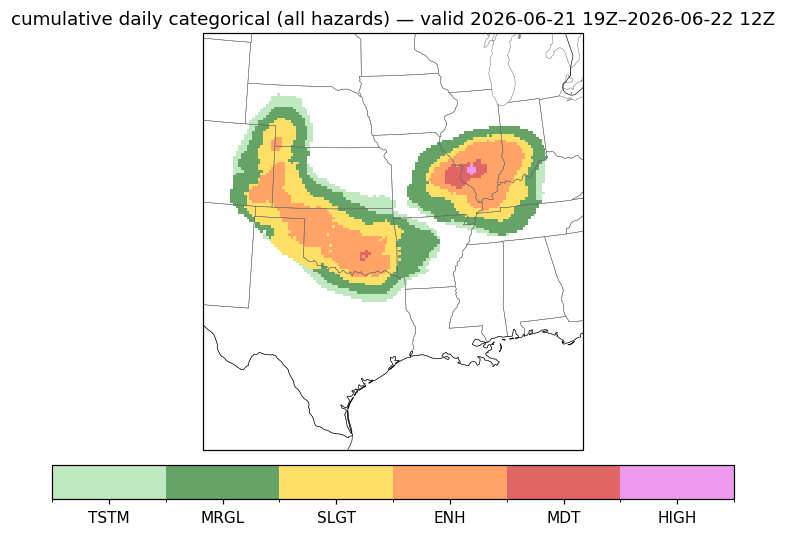

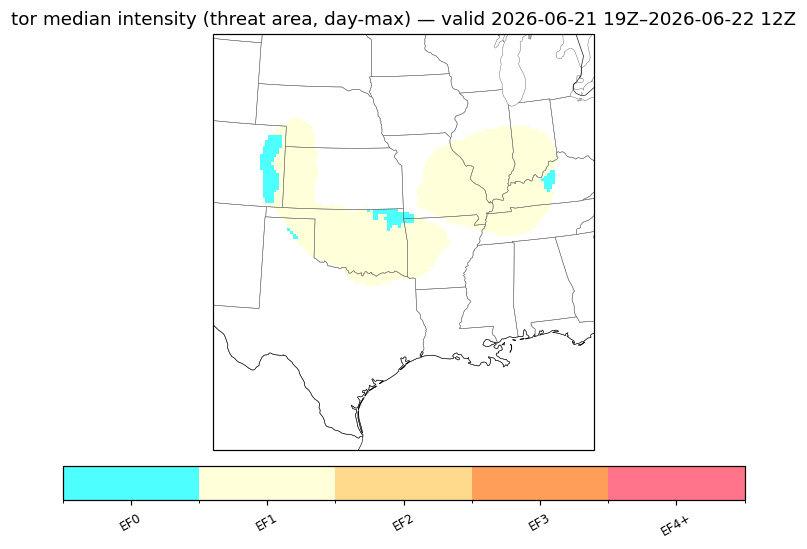

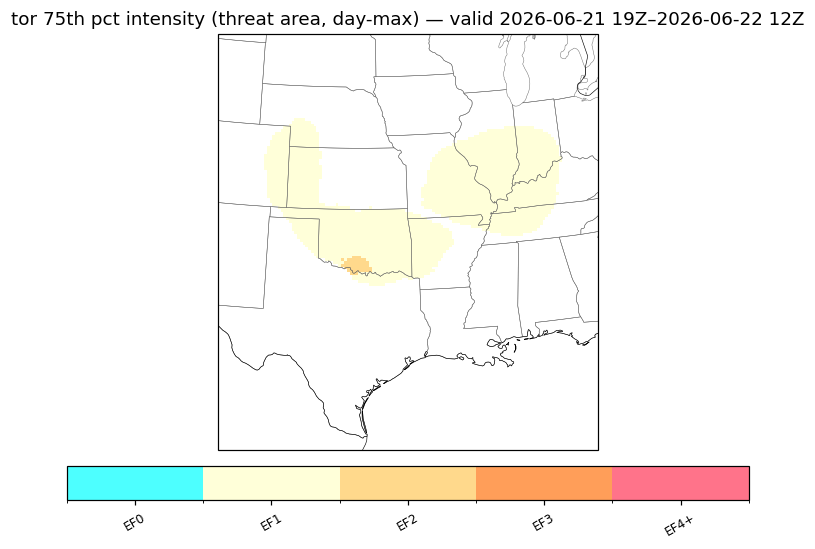

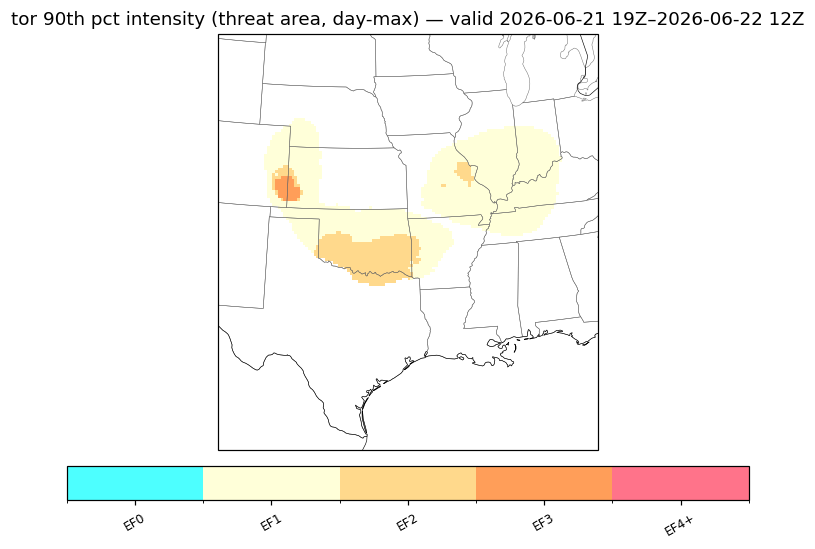

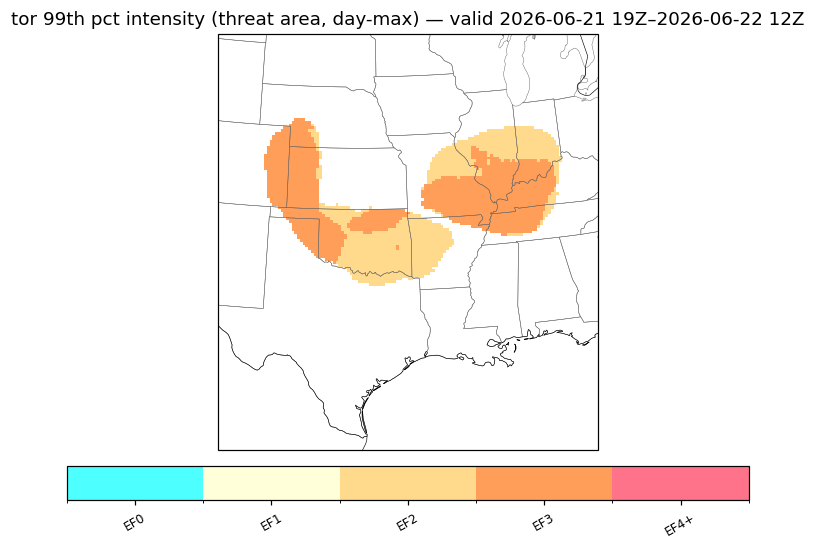

In [7]:
if preds:
    from IPython.display import Image, display
    v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
    period = f'valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}'
    # cumulative daily CATEGORICAL across ALL hazards (SPC-style Day-1 categorical)
    combined = summary.combined_categorical(preds)
    plots.plot_categorical(combined['category'], 'all', f'cumulative daily categorical (all hazards) — {period}', '/tmp/_day.png')
    display(Image('/tmp/_day.png'))
    # day-MAX conditional-intensity bin for the SELECTED HAZARD at the median (q=0.5),
    # 75th (q=0.75), 90th (q=0.90) and 99th (q=0.99) percentile: per-hour percentile bin,
    # then the element-wise max over hours (strongest intensity reached anywhere that
    # day). -1 = no mass; masked to the threat area below.
    daymax_h = summary.day_max({f: preds[f][f'p_{HAZARD}'] for f in FXX})
    for q, qlab in [(0.5, 'median'), (0.75, '75th pct'), (0.90, '90th pct'), (0.99, '99th pct')]:
        qb = np.stack([summary.percentile_intensity_bin(np.nan_to_num(preds[f][f'dist_{HAZARD}']), q) for f in FXX], axis=0).max(axis=0)
        qb = np.where(daymax_h >= C.SPC_PROB_LEVELS[HAZARD][0], qb, -1)  # threat area only
        plots.plot_intensity(qb, HAZARD, f'{HAZARD} {qlab} intensity (threat area, day-max) — {period}', f'/tmp/_int_{HAZARD}_{q}.png')
        display(Image(f'/tmp/_int_{HAZARD}_{q}.png'))

## Day-max probability vs observed reports — ALL hazards

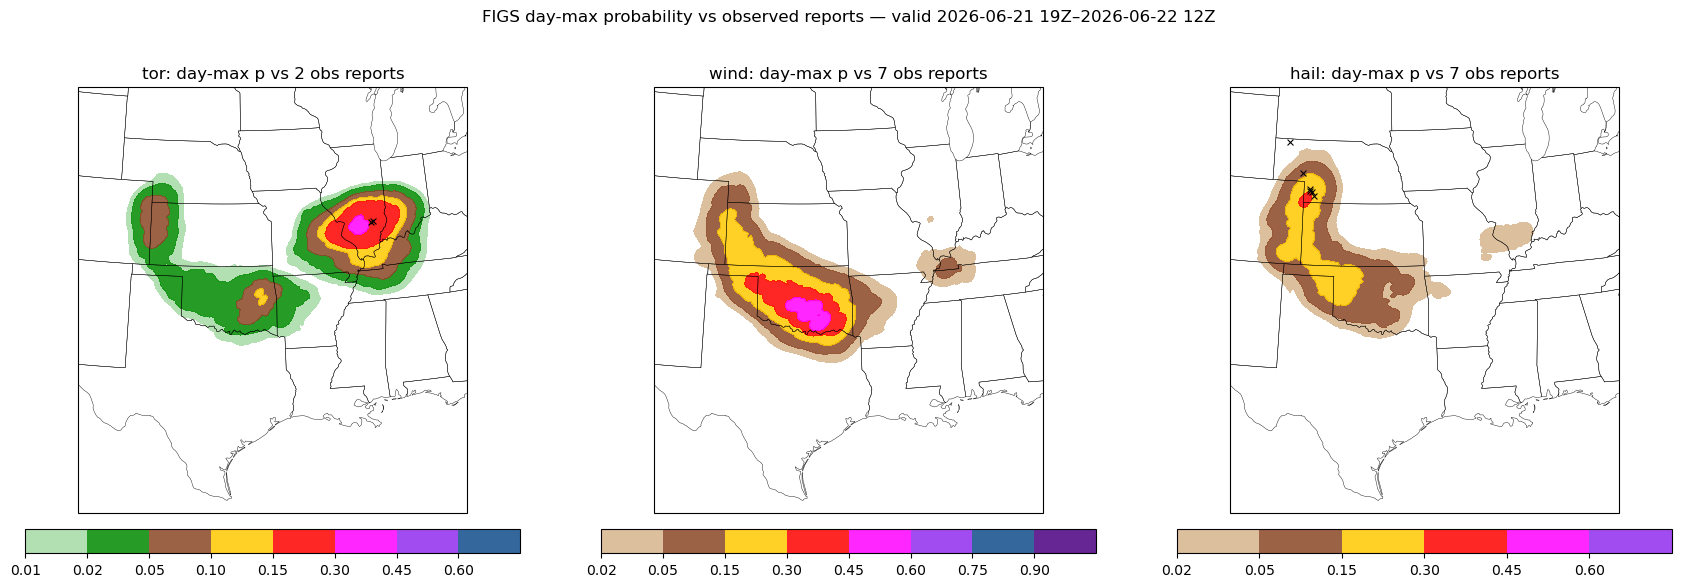

2 tor reports in valid window 2026-06-21 19Z -> 2026-06-22 12Z


In [8]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.data.grid import figs_xy, lcc_forward, figs_latlon
# Observed reports over the FORECAST VALID WINDOW (RUN+min..max FXX). An evening
# event spills past 00Z into the next UTC day, so fetch every UTC day it spans
# and filter to the window — a 00Z-00Z calendar fetch would miss those reports.
v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
udays = sorted({v0.replace(hour=0,minute=0,second=0,microsecond=0),
                v1.replace(hour=0,minute=0,second=0,microsecond=0)})
rep_all = pd.concat([reports.reports_for_day(d) for d in udays], ignore_index=True)
rep_all = rep_all[(rep_all.time >= v0) & (rep_all.time <= v1)]
lat, lon = figs_latlon()
proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
# day-max probability vs observed reports, one panel per hazard (ALL hazards)
fig, axes = plt.subplots(1, 3, figsize=(18,6), subplot_kw={'projection': proj})
for ax, h in zip(axes, C.HAZARDS):
    ax.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
    dmax_h = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX}) if preds else None
    rep_h = rep_all[rep_all.hazard == h]
    lv = list(C.SPC_PROB_LEVELS[h]) + [1.0]
    if dmax_h is not None:
        cf = ax.contourf(lon, lat, dmax_h, levels=lv, colors=plots.PROB_COLORS[h],
                         transform=ccrs.PlateCarree(), alpha=0.85, extend='neither')
        fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, ticks=C.SPC_PROB_LEVELS[h])
    ax.scatter(rep_h.lon, rep_h.lat, s=18, c='black', marker='x', lw=0.8, transform=ccrs.PlateCarree())
    ax.set_title(f'{h}: day-max p vs {len(rep_h)} obs reports')
fig.suptitle(f'FIGS day-max probability vs observed reports — valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}', y=1.02)
plt.tight_layout(); plt.show()
# selected-hazard views kept for the capture (below) + conditional-intensity cells
rep = rep_all[rep_all.hazard == HAZARD].copy()
daymax = summary.day_max({f: preds[f][f'p_{HAZARD}'] for f in FXX}) if preds else None
print(len(rep), HAZARD, 'reports in valid window', f'{v0:%Y-%m-%d %HZ}', '->', f'{v1:%Y-%m-%d %HZ}')

### Capture: what fraction of observed reports fell inside each probability contour?

In [9]:
if preds is not None and len(rep):
    xc, yc = figs_xy(); x, y = lcc_forward(rep.lon.values, rep.lat.values)
    ix = np.round((x-xc[0])/(xc[1]-xc[0])).astype(int); iy = np.round((y-yc[0])/(yc[1]-yc[0])).astype(int)
    ok = (ix>=0)&(ix<len(xc))&(iy>=0)&(iy<len(yc))
    pvals = daymax[iy[ok], ix[ok]]
    print(f'{ok.sum()} in-domain reports | median forecast prob at report sites = {np.median(pvals):.3f}')
    for thr in C.SPC_PROB_LEVELS[HAZARD]:
        print(f'  captured at >= {int(thr*100):>2d}%: {100*(pvals>=thr).mean():5.1f}% of reports')
    # crude reliability for the day: report frequency vs forecast prob bin
    from figs.model.calibrate import reliability
    # (skipped here; see 02_training_progress for full reliability)

2 in-domain reports | median forecast prob at report sites = 0.283
  captured at >=  1%: 100.0% of reports
  captured at >=  2%: 100.0% of reports
  captured at >=  5%: 100.0% of reports
  captured at >= 10%: 100.0% of reports
  captured at >= 15%: 100.0% of reports
  captured at >= 30%:   0.0% of reports
  captured at >= 45%:   0.0% of reports
  captured at >= 60%:   0.0% of reports


### Observed vs predicted conditional intensity

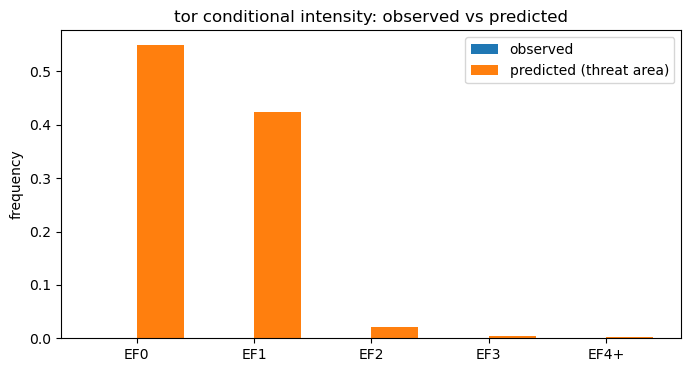

In [10]:
if preds is not None and len(rep):
    from figs.data.labels import intensity_bin
    labels = C.INTENSITY_BINS[HAZARD]['labels']; nb = len(labels)
    # observed intensity histogram (EF for tor; exclude EFU=-1)
    vals = rep.ef.values if HAZARD=='tor' else rep.magnitude.values
    obs = np.zeros(nb)
    for v in vals:
        b = intensity_bin(HAZARD, v)
        if b>=0: obs[b]+=1
    obs = obs/obs.sum() if obs.sum() else obs
    # predicted mean conditional distribution over the threat area (p>=5%)
    dist_day = np.nanmean([np.nan_to_num(preds[f][f'dist_{HAZARD}']) for f in FXX], axis=0)  # (nb,ny,nx)
    mask = daymax >= 0.05
    pred = dist_day[:, mask].mean(axis=1) if mask.any() else np.full(nb, np.nan)
    pred = pred/pred.sum()
    xpos = np.arange(nb); w=0.4
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(xpos-w/2, obs, w, label='observed'); ax.bar(xpos+w/2, pred, w, label='predicted (threat area)')
    ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_ylabel('frequency'); ax.legend()
    ax.set_title(f'{HAZARD} conditional intensity: observed vs predicted'); plt.show()

## 6-panel: FIGS prob+CIG vs SPC outlooks (tornado / wind / hail)

Top row = FIGS day-max probability (SPC colors) with significant (CIG≥2) hatching;
bottom row = the **actual SPC probabilistic outlook contours**, pulled as vectors
from the IEM GIS archive and drawn on the same projection (significant-severe area
hatched). The SPC **day** (1/2/3) is auto-selected from the forecast valid period,
and the issuance closest to RUN is used.

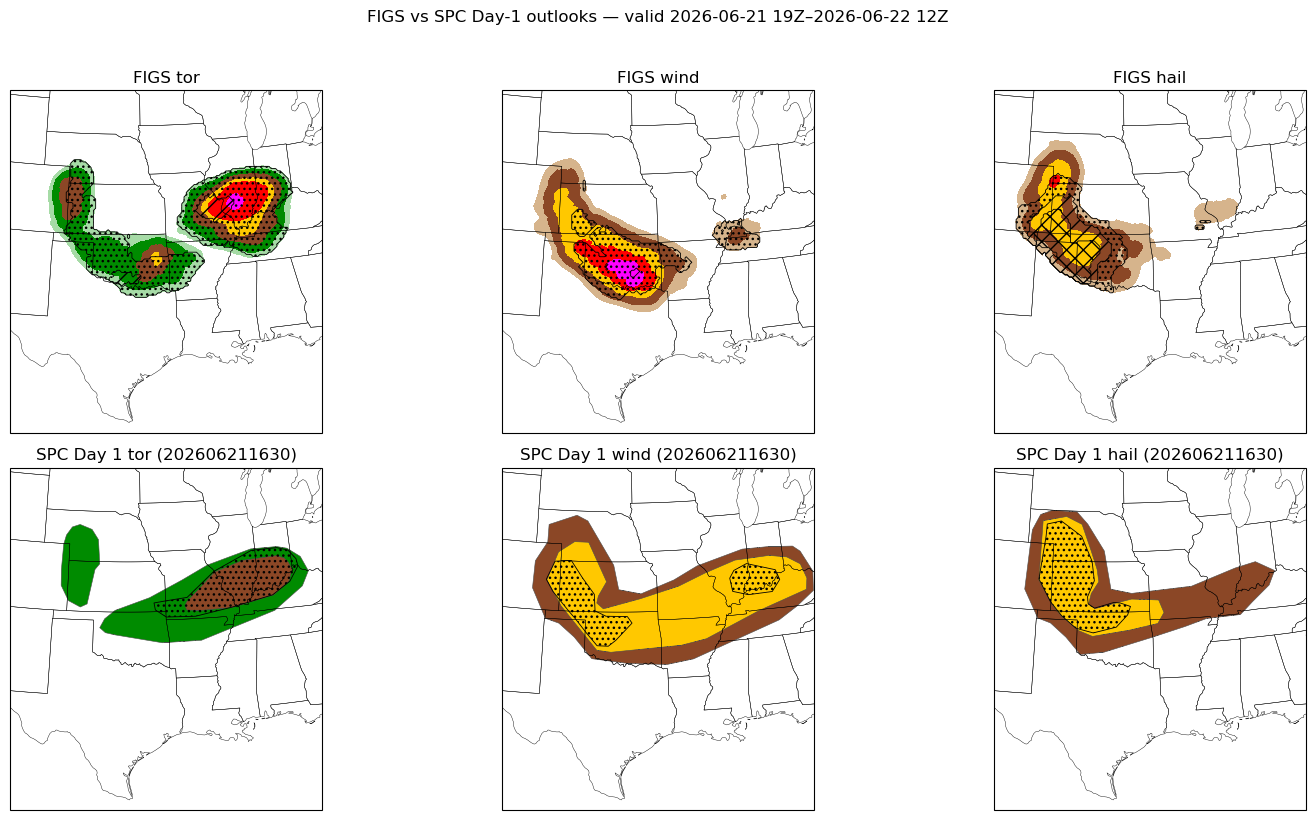

In [11]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.products import cig as cigmod, spc
lat, lon = figs_latlon()
# pick the SPC outlook day matching the forecast valid window (Day 1 vs Day 2 ...)
_v0 = RUN + timedelta(hours=min(FXX)); _v1 = RUN + timedelta(hours=max(FXX))
vmid = _v0 + (_v1 - _v0) / 2
spc_day = spc.outlook_day_for(RUN, vmid)
# actual SPC outlook contours from IEM (vector); valid conv day = vmid, issuance closest to RUN
spc_gdf = None
try:
    spc_gdf = spc.select_issuance(spc.fetch_spc_outlooks(vmid, day=spc_day), RUN, valid_time=vmid)
except Exception as e:
    print('SPC outlook fetch failed:', e)
spc_iss = (sorted(spc_gdf['ISSUE'].unique())[0] if spc_gdf is not None and len(spc_gdf) else 'n/a')
proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
fig = plt.figure(figsize=(16,8))
for j, h in enumerate(['tor','wind','hail']):
    ax = fig.add_subplot(2, 3, j+1, projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
    if preds:
        dmax = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX})
        lv = list(C.SPC_PROB_LEVELS[h]) + [1.0]
        ax.contourf(lon, lat, dmax, levels=lv, colors=plots.PROB_COLORS[h], transform=ccrs.PlateCarree(), extend='neither')
        # CIG derived HOUR-BY-HOUR (per-hour conditional dist), then maxed over
        # hours — matches summary.cumulative_categorical. Averaging the dist first
        # would dilute the upper tail and understate peak severity.
        cigmax = np.stack([cigmod.derive_cig_category(h, np.nan_to_num(preds[f][f'dist_{h}'])) for f in FXX], axis=0).max(axis=0)
        cigcat = np.where(dmax >= C.SPC_PROB_LEVELS[h][0], cigmax, 0)
        plots.overlay_cig(ax, lon, lat, cigcat)  # CIG1 dots / CIG2 diag / CIG3 cross, masked to prob area
    ax.set_title(f'FIGS {h}')
    ax2 = fig.add_subplot(2, 3, j+4, projection=proj)
    ax2.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax2.set_extent(MAP_EXTENT)
    spc.plot_spc_outlook(ax2, spc_gdf, h, plots.PROB_COLORS[h])  # filled by prob threshold + SIGN hatch
    ax2.set_title(f'SPC Day {spc_day} {h} ({spc_iss})')
fig.suptitle(f'FIGS vs SPC Day-{spc_day} outlooks — valid {_v0:%Y-%m-%d %HZ}–{_v1:%Y-%m-%d %HZ}', y=1.02); plt.tight_layout(); plt.show()

## Inspect a saved prediction netCDF

In [12]:
# import xarray as xr
# ds = xr.open_dataset(netcdf.predictions_path(RUN, fxx=FXX)); ds